In [18]:
import pandas as pd
import numpy as np
import pickle
import warnings
from pmdarima import auto_arima
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error
from tqdm import tqdm
warnings.filterwarnings(
    "ignore",
    message=".*force_all_finite.*",
    category=FutureWarning,
    module="sklearn"
)

In [3]:
with open('../data/datasets/data_cleaned.pkl', 'rb') as f:
    states_dfs = pickle.load(f)

In [80]:
target = 'residential_electricity_price'
state = 'IA'
df = states_dfs[state]

In [60]:
class BoostedSarima:

    def __init__(self, n_componets=5, horizon=12):
        self.n_components = n_componets
        self.horizon = horizon
        self.sarima_forecast = None
        self.base_preds = None
        self.preds = None
        self.y_train = None
        self.y_resid_train = None
        self.X_train = None
        self.pca_forecast = None
        self.X_pca = None
        self.pca_pipe = Pipeline(
                                 [
                                    ('scaler', StandardScaler()), 
                                    ('pca', PCA(n_components=n_componets))
                                 ]
                                )
        self.lr_model = None


    def fit(self, X: pd.DataFrame, y: pd.Series):
        self.y_train = y
        self.X_train = X
        self.y_resid_train = y.iloc[-self.horizon:]

        self._get_base_preds()
        self._get_PCA_Forecast()
        self._fit_resid()

    def predict(self):
        self.sarima_forecast = self.sarima_base.predict(self.horizon)
        resid_forecast = self.lr_model.predict(self.pca_forecast)
        self.preds = self.sarima_forecast + resid_forecast
        return self.preds
        


    def _get_base_preds(self):
        self.sarima_base = auto_arima(
            self.y_train, 
            seasonal=True,
            m=self.horizon,
            error_action='ignore',
            max_q = 2,
            max_p = 3,
            max_order = 5,
            trace=True
        )
        start = len(self.y_train) - self.horizon
        self.base_preds = self.sarima_base.predict_in_sample(self.horizon, start=start)

    def _get_PCA_Forecast(self):
        self.X_pca = self.pca_pipe.fit_transform(self.X_train)
        self.pca_forecast = np.zeros(shape=(self.horizon, self.n_components))
        self.pca_sarimas = {}
        for i in range(self.n_components):
            y = self.X_pca[:,i]
            sarima = auto_arima(
                y, 
                seasonal=True,
                m=self.horizon,
                error_action='ignore',
                max_q = 20,
                max_p = 3,
                max_order = 25
            )
            start = len(self.y_train) - self.horizon
            self.pca_forecast[:, i] = sarima.predict(self.horizon, start=start)
            self.pca_sarimas[f'component {i+1}'] = sarima

    def _fit_resid(self):
        start_idx = len(self.y_train) - self.horizon
        X = self.X_pca[start_idx:, :]
        resid = self.y_resid_train - self.base_preds
        self.lr_model = LinearRegression()
        self.lr_model.fit(X, resid)

In [81]:
X, y = df.drop(columns=[target]), df[target]

X_train = X.iloc[:-24]
y_train = y.iloc[:-24]

In [82]:
horizon=24
model = BoostedSarima(n_componets=2, horizon=horizon)
model.fit(X_train, y_train)

Performing stepwise search to minimize aic


KeyboardInterrupt: 

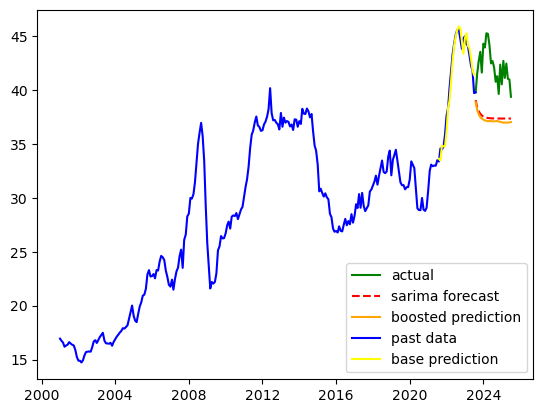

In [75]:
preds = model.predict()
plt.plot(y[-horizon:].index, y[-horizon:], color='green', label='actual')
plt.plot(y[-horizon:].index, model.sarima_forecast, label='sarima forecast', color='red', linestyle='--')
plt.plot(y[-horizon:].index, preds, label='boosted prediction', color='orange')
plt.plot(y[:-horizon+1].index, y[:-horizon+1], color='blue', label='past data')
plt.plot(y[-2*horizon:-horizon].index, model.base_preds, color='yellow', label='base prediction')
plt.legend()
plt.show()


In [76]:
sarima_mape = mean_absolute_percentage_error(model.sarima_forecast, y[-horizon:])
boosted_mape = mean_absolute_percentage_error(preds, y[-horizon:])
print(f'MAPE vs SARIMA: {sarima_mape}')
print(f'MAPE vs BOOSTED: {boosted_mape}')

MAPE vs SARIMA: 0.12262874391603845
MAPE vs BOOSTED: 0.13162572743423467


In [78]:
class ForecastRegression:

    def __init__(self, n_componets=5, horizon=12):
        self.n_components = n_componets
        self.horizon = horizon
        self.preds = None
        self.y_train = None
        self.X_train = None
        self.pca_forecast = None
        self.X_pca = None
        self.pca_pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=n_componets))])
        self.lr_model = None


    def fit(self, X: pd.DataFrame, y: pd.Series):
        self.y_train = y
        self.X_train = X

        self.lr_model = LinearRegression()
        self.X_pca = self.pca_pipe.fit_transform(X)
        self.lr_model.fit(self.X_pca, y)

        self._get_PCA_Forecast()

    def predict(self):
        self.preds = self.lr_model.predict(self.pca_forecast)
        return self.preds
    

    def _get_PCA_Forecast(self):
        self.X_pca = self.pca_pipe.fit_transform(self.X_train)
        self.pca_forecast = np.zeros(shape=(self.horizon, self.n_components))
        self.pca_sarimas = {}
        for i in tqdm(range(self.n_components)):
            y = self.X_pca[:,i]
            sarima = auto_arima(
                y, 
                seasonal=True,
                m=self.horizon,
                error_action='ignore',
                max_q = 2,
                max_p = 3,
                max_order = 2
            )
            start = len(self.y_train) - self.horizon
            self.pca_forecast[:, i] = sarima.predict(self.horizon, start=start)
            self.pca_sarimas[f'component {i+1}'] = sarima
    

In [62]:
model = ForecastRegression(n_componets=2, horizon=horizon)
model.fit(X_train, y_train)
base_preds = model.lr_model.predict(model.X_pca)

100%|██████████| 2/2 [00:48<00:00, 24.13s/it]


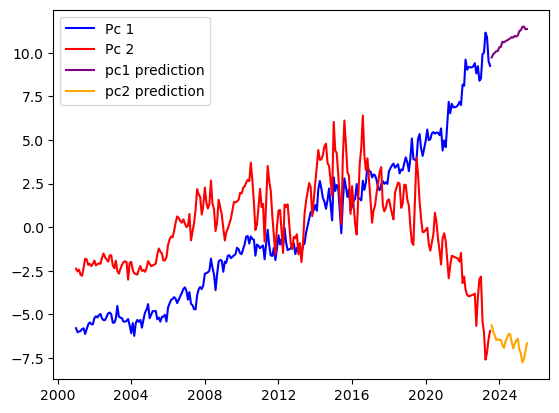

In [88]:
plt.plot(y[:-horizon].index, model.X_pca[:, 0], color='blue', label='Pc 1')
plt.plot(y[:-horizon].index, model.X_pca[:, 1], color='red', label='Pc 2')
plt.plot(y[-horizon:].index, model.pca_forecast[:, 0], label='pc1 prediction', color='purple')
plt.plot(y[-horizon:].index, model.pca_forecast[:, 1], label='pc2 prediction', color='orange')
plt.legend()
plt.show()

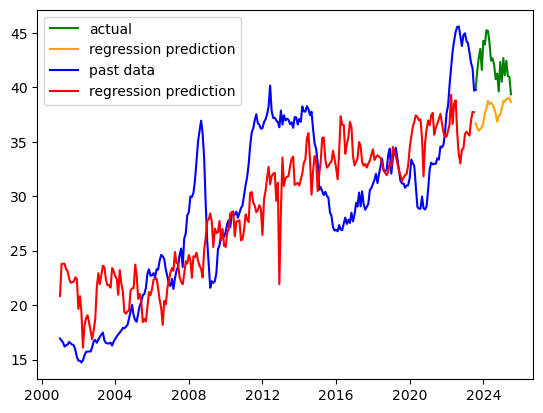

In [64]:
preds = model.predict()
plt.plot(y[-horizon:].index, y[-horizon:], color='green', label='actual')
plt.plot(y[-horizon:].index, preds, label='regression prediction', color='orange')
plt.plot(y[:-horizon+1].index, y[:-horizon+1], color='blue', label='past data')
plt.plot(y[:-horizon].index, base_preds, color='red', label='regression prediction')
plt.legend()
plt.show()

In [49]:
regression_mape = mean_absolute_percentage_error(preds, y[-horizon:])
print(f'Regression Mape: {regression_mape}')

Regression Mape: 0.11417775155055261


In [65]:
from sklearn.ensemble import RandomForestRegressor

In [108]:
class RandomForrestForecaster:

    def __init__(self, n_componets=5, horizon=12, n_estimators=100, random_state=42):
        self.n_components = n_componets
        self.horizon = horizon
        self.preds = None
        self.y_train = None
        self.X_train = None
        self.pca_forecast = None
        self.X_pca = None
        self.pca_pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=n_componets))])
        self.rf_model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)


    def fit(self, X: pd.DataFrame, y: pd.Series, trace: bool=False):
        self.y_train = y
        self.X_train = X

        self.X_pca = self.pca_pipe.fit_transform(X)
        self.rf_model.fit(self.X_pca, y)

        self._get_PCA_Forecast(trace=trace)

    def predict(self):
        self.preds = self.rf_model.predict(self.pca_forecast)
        return self.preds
    

    def _get_PCA_Forecast(self, trace=False):
        self.X_pca = self.pca_pipe.fit_transform(self.X_train)
        self.pca_forecast = np.zeros(shape=(self.horizon, self.n_components))
        self.pca_sarimas = {}
        for i in tqdm(range(self.n_components)):
            if trace:
                print(f'forcasting PCA Component {i+1}')
            y = self.X_pca[:,i]
            sarima = auto_arima(
                y, 
                seasonal=True,
                m=self.horizon,
                error_action='ignore',
                max_q = 5,
                max_p = 5,
                max_order = 10,
                trace=trace
            )
            start = len(self.y_train) - self.horizon
            self.pca_forecast[:, i] = sarima.predict(self.horizon, start=start)
            self.pca_sarimas[f'component {i+1}'] = sarima
    

In [109]:
model = RandomForrestForecaster(n_componets=5, horizon=horizon)
model.fit(X_train, y_train, trace=True)

  0%|          | 0/5 [00:00<?, ?it/s]

forcasting PCA Component 1
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=405.577, Time=1.04 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=431.110, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=421.410, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=414.452, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=432.035, Time=0.00 sec
 ARIMA(2,1,2)(0,0,1)[24] intercept   : AIC=403.712, Time=0.68 sec
 ARIMA(2,1,2)(0,0,0)[24] intercept   : AIC=406.057, Time=0.16 sec
 ARIMA(2,1,2)(0,0,2)[24] intercept   : AIC=405.665, Time=3.63 sec
 ARIMA(2,1,2)(1,0,0)[24] intercept   : AIC=403.828, Time=0.72 sec
 ARIMA(2,1,2)(1,0,2)[24] intercept   : AIC=407.711, Time=3.88 sec
 ARIMA(1,1,2)(0,0,1)[24] intercept   : AIC=402.486, Time=0.42 sec
 ARIMA(1,1,2)(0,0,0)[24] intercept   : AIC=405.115, Time=0.06 sec
 ARIMA(1,1,2)(1,0,1)[24] intercept   : AIC=404.436, Time=0.71 sec
 ARIMA(1,1,2)(0,0,2)[24] intercept   : AIC=404.475, Time=1.86 sec
 ARIMA

 20%|██        | 1/5 [00:25<01:41, 25.30s/it]

 ARIMA(1,1,3)(0,0,1)[24] intercept   : AIC=405.466, Time=1.29 sec
 ARIMA(0,1,2)(0,0,1)[24]             : AIC=409.950, Time=0.09 sec

Best model:  ARIMA(0,1,2)(0,0,1)[24] intercept
Total fit time: 25.278 seconds
forcasting PCA Component 2
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=688.309, Time=0.91 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=738.077, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=728.054, Time=0.09 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=730.964, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=736.130, Time=0.00 sec
 ARIMA(2,1,2)(0,0,1)[24] intercept   : AIC=697.792, Time=0.37 sec
 ARIMA(2,1,2)(1,0,0)[24] intercept   : AIC=694.951, Time=0.38 sec
 ARIMA(2,1,2)(2,0,1)[24] intercept   : AIC=690.277, Time=4.48 sec
 ARIMA(2,1,2)(1,0,2)[24] intercept   : AIC=690.285, Time=3.70 sec
 ARIMA(2,1,2)(0,0,0)[24] intercept   : AIC=704.667, Time=0.07 sec
 ARIMA(2,1,2)(0,0,2)[24] intercept   : AIC=693.144, Time=1.

 40%|████      | 2/5 [01:22<02:11, 43.99s/it]

...

 ARIMA(2,0,1)(2,0,0)[24]             : AIC=823.670, Time=0.54 sec

Best model:  ARIMA(1,0,0)(2,0,0)[24]          
Total fit time: 11.322 seconds
forcasting PCA Component 4
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=652.723, Time=1.08 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=1052.196, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=671.512, Time=0.13 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=843.127, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=1050.196, Time=0.00 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=673.517, Time=0.58 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=670.153, Time=0.55 sec
 ARIMA(2,0,2)(2,0,1)[24] intercept   : AIC=653.503, Time=4.17 sec
 ARIMA(2,0,2)(1,0,2)[24] intercept   : AIC=654.107, Time=4.28 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=679.895, Time=0.09 sec
 ARIMA(2,0,2)(0,0,2)[24] intercept   : AIC=669.352, Time=2.97 sec
 ARIMA(2,0,2)(2,0,0)[24] intercept   : AIC=661.620, Time=

 80%|████████  | 4/5 [02:33<00:41, 41.38s/it]

 ARIMA(2,0,1)(1,0,1)[24]             : AIC=650.205, Time=0.35 sec

Best model:  ARIMA(1,0,0)(1,0,1)[24]          
Total fit time: 60.156 seconds
forcasting PCA Component 5
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=1.22 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=926.996, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=678.527, Time=0.18 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=771.439, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=924.996, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=679.064, Time=0.01 sec
 ARIMA(1,0,0)(2,0,0)[24] intercept   : AIC=679.560, Time=0.68 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(1,0,0)(0,0,1)[24] intercept   : AIC=678.765, Time=0.10 sec
 ARIMA(1,0,0)(2,0,1)[24] intercept   : AIC=inf, Time=2.33 sec
 ARIMA(0,0,0)(1,0,0)[24] intercept   : AIC=928.469, Time=0.05 sec
 ARIMA(2,0,0)(1,0,0)[24] intercept   : AIC=680.434, Time=0.16 sec
 ARIM

100%|██████████| 5/5 [02:42<00:00, 32.40s/it]

 ARIMA(0,0,1)(1,0,0)[24]             : AIC=769.689, Time=0.05 sec
 ARIMA(2,0,1)(1,0,0)[24]             : AIC=680.024, Time=0.15 sec

Best model:  ARIMA(1,0,0)(1,0,0)[24]          
Total fit time: 8.051 seconds


In [111]:
base_preds = model.rf_model.predict(model.X_pca)

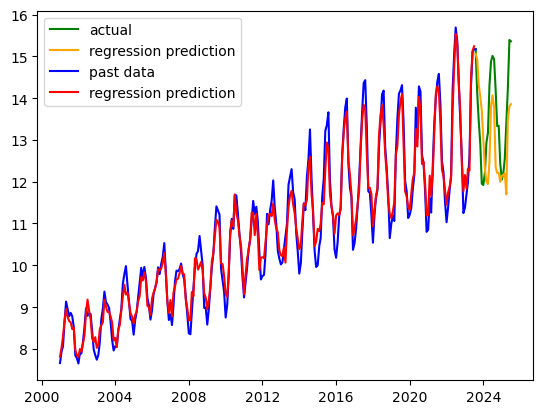

In [112]:
preds = model.predict()
plt.plot(y[-horizon:].index, y[-horizon:], color='green', label='actual')
plt.plot(y[-horizon:].index, preds, label='regression prediction', color='orange')
plt.plot(y[:-horizon+1].index, y[:-horizon+1], color='blue', label='past data')
plt.plot(y[:-horizon].index, base_preds, color='red', label='regression prediction')
plt.legend()
plt.show()

In [113]:
regression_mape = mean_absolute_percentage_error(preds, y[-horizon:])
print(f'Regression Mape: {regression_mape}')

Regression Mape: 0.07535347569549693
